In [6]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from matplotlib import pyplot as plt

np.random.seed(42)

In [28]:
# Estructura
N_SERIES = 40
N_SEGMENTS = 23
MAX_CLUSTERS_TRUE = 3

# Parámetros jerárquicos verdaderos
mu_global_true = 0.4
sigma_global_true = 0.05

tau_init_true = 0.02

# Random Walk verdadero
b_true = 0.04
# kappa_true = 3.0   # penaliza ascensos
kappa_true = 2.0   # penaliza ascensos
SIGMA_MODIS = 0.03

# Pesos verdaderos de clusters
pi_true = np.array([0.5, 0.3, 0.2])

In [29]:
np.random.seed(42)

In [30]:
# Media por cluster
mu0_true = np.random.normal(mu_global_true, sigma_global_true, MAX_CLUSTERS_TRUE)

# Nivel inicial
a0_true = np.random.normal(mu0_true, tau_init_true)

# Generar incrementos asimétricos manualmente
def asymmetric_laplace(size, b, kappa):
    u = np.random.uniform(size=size)
    return np.where(
        u < kappa/(1+kappa),
        np.random.exponential(b/kappa, size=size),
        -np.random.exponential(b, size=size)
    )

delta_true = asymmetric_laplace(
    (MAX_CLUSTERS_TRUE, N_SEGMENTS-1),
    b_true,
    kappa_true
)

# Construcción del RW
a_true = np.zeros((MAX_CLUSTERS_TRUE, N_SEGMENTS))
a_true[:, 0] = a0_true

for t in range(1, N_SEGMENTS):
    a_true[:, t] = a_true[:, t-1] + delta_true[:, t-1]

Generar series observadas

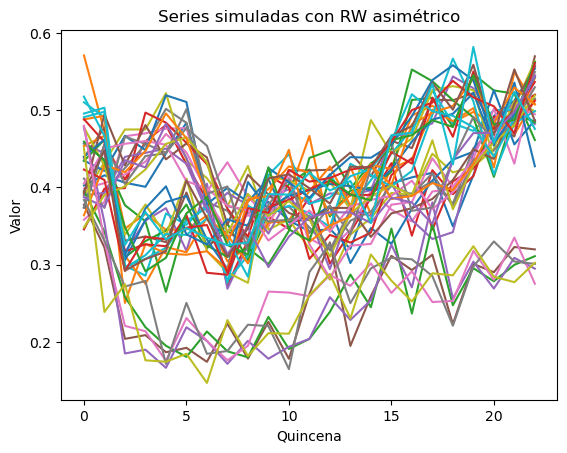

In [31]:
z_true = np.random.choice(MAX_CLUSTERS_TRUE, size=N_SERIES, p=pi_true)

series_values = []
series_bins = []

for i in range(N_SERIES):
    cluster = z_true[i]
    
    bins = np.arange(N_SEGMENTS)
    mu_series = a_true[cluster, :]
    
    y = np.random.normal(mu_series, SIGMA_MODIS)
    
    series_bins.append(bins)
    series_values.append(y)
    plt.plot(bins, y)
plt.xlabel("Quincena")
plt.ylabel("Valor")
plt.title("Series simuladas con RW asimétrico")
plt.show()

ajustar modelo

In [32]:
ALPHA_DP = 3.0
MAX_CLUSTERS = 6  # sobreespecificamos

In [33]:
def build_model(series_bins, series_values):

    n_series = len(series_values)

    with pm.Model() as model:

        # Stick-breaking
        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pt.concatenate(
                [beta[0:1],
                 beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])]
            )
        )
        pi = pi / pt.sum(pi)

        # Hiperprior
        mu_global = pm.Normal("mu_global", 0.5, 0.3)
        sigma_global = pm.HalfNormal("sigma_global", 0.2)

        mu0 = pm.Normal("mu0", mu_global, sigma_global,
                        shape=MAX_CLUSTERS)

        tau_init = pm.HalfNormal("tau_init", 0.1)

        a0 = pm.Normal("a0", mu0, tau_init,
                       shape=MAX_CLUSTERS)

        # RW asimétrico
        b = pm.HalfNormal("b_rw", 0.1)
        kappa = pm.HalfNormal("kappa_rw", 3.0)

        delta = pm.AsymmetricLaplace(
            "delta",
            mu=0,
            b=b,
            kappa=kappa,
            shape=(MAX_CLUSTERS, N_SEGMENTS-1)
        )

        a = pm.Deterministic(
            "a",
            pt.concatenate(
                [
                    a0[:, None],
                    a0[:, None] + pt.cumsum(delta, axis=1)
                ],
                axis=1
            )
        )

        z = pm.Categorical("z", p=pi, shape=n_series)

        for i in range(n_series):
            mu_i = a[z[i], series_bins[i]]

            pm.Normal(
                f"y_{i}",
                mu=mu_i,
                sigma=SIGMA_MODIS,
                observed=series_values[i]
            )

    return model

In [34]:
model = build_model(series_bins, series_values)

with model:
    trace = pm.sample(
        1000,
        tune=500,
        target_accept=0.9,
        chains=2
    )

/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pytensor/tensor/math.py:1115: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
Multi

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 324 seconds.
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [35]:
az.summary(trace, var_names=["mu_global", "b_rw", "kappa_rw"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,0.431,0.158,0.152,0.778,0.011,0.012,232.0,230.0,1.01
b_rw,0.473,0.071,0.349,0.611,0.004,0.002,262.0,594.0,1.01
kappa_rw,1.074,0.227,0.686,1.525,0.015,0.010,235.0,442.0,1.00


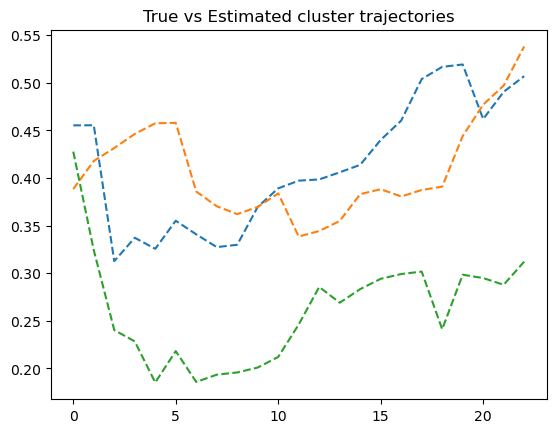

In [39]:
posterior_a = trace.posterior["a"].mean(dim=("chain","draw")).values

plt.figure()
for k in range(MAX_CLUSTERS_TRUE):
    plt.plot(a_true[k], linestyle="--")
    # plt.plot(posterior_a[k])
plt.title("True vs Estimated cluster trajectories")
plt.show()